In [47]:
from cellpose import models
from cellpose.io import imread
import os, cv2, glob, re, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.morphology import disk, binary_dilation, binary_erosion
from skimage.filters import median
from skimage import io
from skimage.measure import label
from skimage.registration import phase_cross_correlation
from scipy.ndimage import gaussian_filter
from skimage.measure import regionprops
from skimage import measure
from skimage.measure import regionprops_table

Found 25 channel 1 images
Found 25 channel 2 images


/tmp/ipykernel_2682807/1459925917.py:68: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


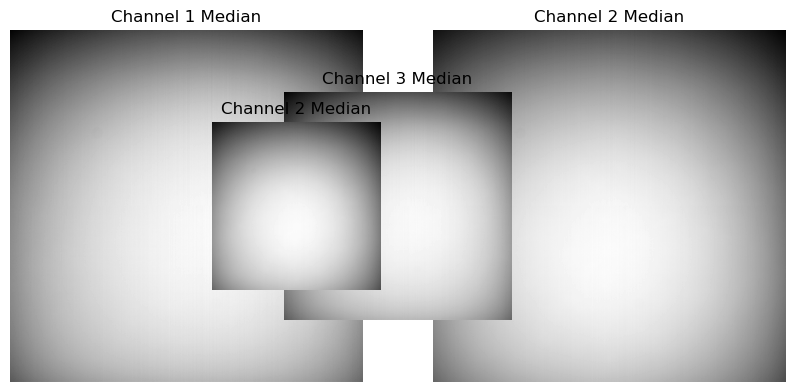

Saved:
/mnt/upsuter/upsuter-raw/Marko/mESC-rep2-all-proteins/median_ch1.tiff
/mnt/upsuter/upsuter-raw/Marko/mESC-rep2-all-proteins/median_ch2.tiff


In [30]:
import os
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt

def load_images_by_channel(folder_path):
    ch1_images = []
    ch2_images = []
    ch3_images = []
    ch4_images = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".tiff"):
            full_path = os.path.join(folder_path, filename)

            if filename.endswith("-ch1sk1fk1fl1.tiff"):
                img = tiff.imread(full_path)
                ch1_images.append(img)

            elif filename.endswith("-ch2sk1fk1fl1.tiff"):
                img = tiff.imread(full_path)
                ch2_images.append(img)
            elif filename.endswith("-ch3sk1fk1fl1.tiff"):
                img = tiff.imread(full_path)
                ch3_images.append(img)
            elif filename.endswith("-ch4sk1fk1fl1.tiff"):
                img = tiff.imread(full_path)
                ch4_images.append(img)

    return ch1_images, ch2_images, ch3_images, ch4_images


def compute_median_image(image_list):
    if len(image_list) == 0:
        raise ValueError("No images found for this channel.")

    # Stack into 3D array (n_images, height, width)
    stack = np.stack(image_list, axis=0)

    # Compute median along the stack axis
    median_img = np.median(stack, axis=0)

    return median_img.astype(stack.dtype)


def plot_images(ch1_img, ch2_img, ch3_img, ch4_img):
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(ch1_img, cmap='gray')
    plt.title("Channel 1 Median")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(ch2_img, cmap='gray')
    plt.title("Channel 2 Median")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(ch3_img, cmap='gray')
    plt.title("Channel 3 Median")
    plt.axis('off')
    
    plt.subplot(1, 4, 2)
    plt.imshow(ch4_img, cmap='gray')
    plt.title("Channel 2 Median")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()


def save_images(ch1_img, ch2_img, ch3_img, ch4_img, output_folder):
    os.makedirs(output_folder, exist_ok=True)

    ch1_path = os.path.join(output_folder, "median_ch1.tiff")
    ch2_path = os.path.join(output_folder, "median_ch2.tiff")
    ch3_path = os.path.join(output_folder, "median_ch3.tiff")
    ch4_path = os.path.join(output_folder, "median_ch4.tiff")

    tiff.imwrite(ch1_path, ch1_img)
    tiff.imwrite(ch2_path, ch2_img)
    tiff.imwrite(ch3_path, ch3_img)
    tiff.imwrite(ch4_path, ch4_img)

    print(f"Saved:\n{ch1_path}\n{ch2_path}")


def main(folder_path, output_folder):
    ch1_images, ch2_images, ch3_images, ch4_images = load_images_by_channel(folder_path)

    print(f"Found {len(ch1_images)} channel 1 images")
    print(f"Found {len(ch2_images)} channel 2 images")

    ch1_median = compute_median_image(ch1_images)
    ch2_median = compute_median_image(ch2_images)
    ch3_median = compute_median_image(ch1_images)
    ch4_median = compute_median_image(ch2_images)
    
    plot_images(ch1_median, ch2_median, ch3_median, ch4_median)
    save_images(ch1_median, ch2_median, ch3_median, ch4_median, output_folder)


if __name__ == "__main__":
    input_folder = "/mnt/upsuter/upsuter-raw/Marko/mESC-rep2-all-proteins/FOV"
    output_folder = "/mnt/upsuter/upsuter-raw/Marko/mESC-rep2-all-proteins/"

    main(input_folder, output_folder)

In [48]:
# ============================================================
# Utilities
# ============================================================
def to_uint8(x):
    x = np.asarray(x, dtype=np.float32)
    den = x.max() - x.min()
    if den <= 0:
        return np.zeros_like(x, dtype=np.uint8)
    return (255 * (x - x.min()) / (den + 1e-12)).astype(np.uint8)


def to_uint16(x):
    x = np.asarray(x, dtype=np.float32)
    den = x.max() - x.min()
    if den <= 0:
        return np.zeros_like(x, dtype=np.uint16)
    return (65535 * (x - x.min()) / (den + 1e-12)).astype(np.uint16)


def overlay_mask_quiet(bg, mask2d, title_bg="BG", title_ov="Overlay", alpha=0.30):
    bg_u8 = to_uint8(bg)
    bg_rgb = cv2.cvtColor(bg_u8, cv2.COLOR_GRAY2RGB)
    overlay = np.zeros_like(bg_rgb, dtype=np.uint8)
    rng = np.random.RandomState(42)
    for cid in np.unique(mask2d):
        if cid == 0:
            continue
        color = rng.randint(0, 256, 3, dtype=np.uint8)
        overlay[mask2d == cid] = color
    out = cv2.addWeighted(bg_rgb.astype(np.float32), 1 - alpha,
                          overlay.astype(np.float32), alpha, 0).astype(np.uint8)
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title(title_bg)
    plt.imshow(bg_rgb)
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.title(title_ov)
    plt.imshow(out)
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    plt.close()


# ============================================================
# Alignment helpers
# ============================================================
def _to_bool_mask(x):
    arr = io.imread(x) if isinstance(x, str) else np.asarray(x)
    if arr.ndim == 3:
        arr = arr[..., 0]
    return (arr > 0).astype(np.uint8)


def apply_integer_shift(img, dy, dx, out_shape=None):
    M = np.asarray(img)
    H, W = M.shape[:2]
    if out_shape is None:
        out_shape = (H, W) if M.ndim == 2 else (H, W, M.shape[2])
    out = np.zeros(out_shape, dtype=M.dtype)
    Ho, Wo = out_shape[:2]
    y0_dst, x0_dst = max(0, dy), max(0, dx)
    y1_dst, x1_dst = min(Ho, dy + H), min(Wo, dx + W)
    y0_src, x0_src = max(0, -dy), max(0, -dx)
    y1_src, x1_src = y0_src + (y1_dst - y0_dst), x0_src + (x1_dst - x0_dst)
    if (y1_dst > y0_dst) and (x1_dst > x0_dst):
        if M.ndim == 2:
            out[y0_dst:y1_dst, x0_dst:x1_dst] = M[y0_src:y1_src, x0_src:x1_src]
        else:
            out[y0_dst:y1_dst, x0_dst:x1_dst, :] = M[y0_src:y1_src, x0_src:x1_src, :]
    return out


def coverage(A, B):
    A = _to_bool_mask(A)
    B = _to_bool_mask(B)
    inter = np.logical_and(A, B).sum()
    areaA = A.sum()
    return (inter / float(areaA) if areaA > 0 else 0.0), int(inter), int(areaA)


def _bbox_union(a, b, pad=32):
    M = (a.astype(bool) | b.astype(bool))
    ys, xs = np.where(M)
    if len(ys) == 0:
        H, W = a.shape[:2]
        return slice(0, H), slice(0, W)
    H, W = a.shape[:2]
    y1, y2 = max(0, ys.min() - pad), min(H, ys.max() + 1 + pad)
    x1, x2 = max(0, xs.min() - pad), min(W, xs.max() + 1 + pad)
    return slice(y1, y2), slice(x1, x2)


def _resize_mask_nearest(m, fx=0.5, fy=0.5):
    if fx == 1.0 and fy == 1.0:
        return m
    h, w = m.shape[:2]
    nh, nw = max(1, int(round(h * fy))), max(1, int(round(w * fx)))
    return cv2.resize(m, (nw, nh), interpolation=cv2.INTER_NEAREST)


def find_best_shift_fast(mask_ref, mask_shifted, downsample=2, pad=32):
    A = _to_bool_mask(mask_ref).astype(np.float32)
    B = _to_bool_mask(mask_shifted).astype(np.float32)
    if A.sum() == 0 or B.sum() == 0:
        return 0, 0, 0.0
    ys, xs = _bbox_union(A, B, pad=pad)
    Ac = A[ys, xs]
    Bc = B[ys, xs]
    if downsample and downsample > 1:
        inv = 1.0 / float(downsample)
        Ar = _resize_mask_nearest(Ac, fx=inv, fy=inv)
        Br = _resize_mask_nearest(Bc, fx=inv, fy=inv)
    else:
        Ar, Br = Ac, Bc
        downsample = 1
    shift, error, _ = phase_cross_correlation(Ar, Br, upsample_factor=1)
    dy_r, dx_r = float(shift[0]), float(shift[1])
    dy = int(round(dy_r * downsample))
    dx = int(round(dx_r * downsample))
    aligned = apply_integer_shift(B, dy, dx, out_shape=A.shape)
    iou, inter, uni = coverage(A, aligned)
    return dy, dx, float(iou)


def align_masks(mask_ref, mask_shifted, override=None, use_fast=True, ds=2):
    ref = _to_bool_mask(mask_ref)
    if override is None:
        if use_fast:
            dy, dx, score = find_best_shift_fast(ref, mask_shifted, downsample=ds, pad=32)
        else:
            dy, dx = 0, 0
    else:
        dy, dx = override
    aligned = apply_integer_shift(mask_shifted, dy, dx, out_shape=ref.shape)
    cov, inter, areaA = coverage(ref, aligned)
    iou = cov  # coverage here is |A∩B|/|A|
    return (dy, dx), aligned, {
        "dy": int(dy), "dx": int(dx),
        "iou": float(iou),
        "intersection": int(inter),
        "union": int(areaA)
    }


# ----------------------------
# Matching: TL label <-> IF label (overlap-based, 1-to-1)
# ----------------------------
def _contingency_table(lbl_a: np.ndarray, lbl_b: np.ndarray) -> np.ndarray:
    """
    Build contingency/overlap table C where C[i, j] = #pixels where (lbl_a == i) AND (lbl_b == j).
    Background is label 0 in both.
    """
    a = lbl_a.astype(np.int64, copy=False)
    b = lbl_b.astype(np.int64, copy=False)
    na = int(a.max()) + 1
    nb = int(b.max()) + 1
    # combine indices into single bincount
    idx = a.ravel() * nb + b.ravel()
    counts = np.bincount(idx, minlength=na * nb)
    return counts.reshape(na, nb)


def match_labels_by_overlap(
    tl_mask: np.ndarray,
    if_mask: np.ndarray,
    iou_thr: float = 0.10,
    min_overlap_px: int = 30,
    min_frac_tl: float = 0.20,
    min_frac_if: float = 0.20,
) -> pd.DataFrame:
    """
    Returns a dataframe with one-to-one matches:
    columns: tl_label, if_label, overlap_px, iou, frac_tl, frac_if
    """
    if tl_mask.shape != if_mask.shape:
        raise ValueError(f"Shape mismatch: TL {tl_mask.shape} vs IF {if_mask.shape}")

    C = _contingency_table(if_mask, tl_mask)  # rows=IF labels, cols=TL labels
    # Remove background row/col for matching; keep full for area lookup
    overlap = C[1:, 1:]  # shape (n_if, n_tl)

    if overlap.size == 0:
        return pd.DataFrame(columns=["tl_label", "if_label", "overlap_px", "iou", "frac_tl", "frac_if"])

    # Areas from contingency table (pixel counts per label)
    area_if = C.sum(axis=1)  # includes background at index 0
    area_tl = C.sum(axis=0)

    # Candidate pairs: any positive overlap
    if_ids, tl_ids = np.nonzero(overlap)
    # Convert to real labels (+1 because we removed background)
    if_labels = if_ids + 1
    tl_labels = tl_ids + 1
    overlap_px = overlap[if_ids, tl_ids].astype(np.int64)

    # Compute IoU and overlap fractions
    a_if = area_if[if_labels].astype(np.float64)
    a_tl = area_tl[tl_labels].astype(np.float64)
    union = a_if + a_tl - overlap_px
    iou = overlap_px / np.maximum(union, 1.0)
    frac_if = overlap_px / np.maximum(a_if, 1.0)
    frac_tl = overlap_px / np.maximum(a_tl, 1.0)

    cand = pd.DataFrame(
        {
            "tl_label": tl_labels,
            "if_label": if_labels,
            "overlap_px": overlap_px,
            "iou": iou,
            "frac_tl": frac_tl,
            "frac_if": frac_if,
        }
    )

    # Filter by thresholds
    cand = cand[
        (cand["overlap_px"] >= min_overlap_px)
        & (cand["iou"] >= iou_thr)
        & (cand["frac_tl"] >= min_frac_tl)
        & (cand["frac_if"] >= min_frac_if)
    ].copy()

    if cand.empty:
        return cand

    # Enforce one-to-one mapping using greedy selection by highest IoU (then overlap)
    cand.sort_values(["iou", "overlap_px"], ascending=[False, False], inplace=True)

    used_tl = set()
    used_if = set()
    keep_rows = []
    for _, row in cand.iterrows():
        tl = int(row["tl_label"])
        iff = int(row["if_label"])
        if (tl not in used_tl) and (iff not in used_if):
            keep_rows.append(row)
            used_tl.add(tl)
            used_if.add(iff)

    matches = pd.DataFrame(keep_rows).reset_index(drop=True)
    return matches

# ----------------------------
# Measurements: morphology + intensity (per mask)
# ----------------------------
def measure_mean_and_sum(mask: np.ndarray, intensities: dict, prefix: str) -> pd.DataFrame:
    """
    Returns a dataframe indexed by label with:
      - {prefix}_area
      - {prefix}_{ch}_mean
      - {prefix}_{ch}_sum
    """
    # area per label
    base = pd.DataFrame(regionprops_table(mask, properties=["label", "area"]))
    base = base.rename(columns={"area": f"area_{prefix}"}).set_index("label")

    for ch, img in intensities.items():
        tab = pd.DataFrame(
            regionprops_table(
                mask,
                intensity_image=img.astype(np.float32, copy=False),
                properties=["label", "mean_intensity"],
            )
        ).set_index("label")

        base[f"mean_{prefix}_{ch}"] = tab["mean_intensity"]
        base[f"sum_{prefix}_{ch}"] = base[f"mean_{prefix}_{ch}"] * base[f"area_{prefix}"]

    return base


In [49]:
#if_tef1_h2b_dir = #"/mnt/upsuter/upsuter-raw/Marko/260210-3T3-rep1-TEF1-H3_3/3T3_SLT_IF_TEAD1_H2B_rep1_Marko__2026-02-13T15_49_19-Measurement 1/Images"
#tl_tef1_h2b_dir = "Z:\\EPFL\\Biology\\bachelor\\260210-3T3-rep1-TEF1-H2B-20260325T092055Z-3-001\\260210-3T3-rep1-TEF1-H2B\\3T3_SLT_live-cell_rep1_Marko__2026-02-10T14_19_00-Measurement 1\\Images"#"//mnt/upsuter/upsuter-raw/Marko/260210-3T3-rep1-TEF1-H3_3/3T3_SLT_live-cell_rep1_Marko__2026-02-10T14_19_00-Measurement 1/Images"

#if_gapdh_pol2_brg1_dir2 = "/mnt/upsuter/upsuter-raw/Marko/260212-3T3-rep1-GAPDH-BRG1-PolII/3T3_SLT_IF_GAPDH_PolII_BRG1_rep1_Marko__2026-02-13T15_57_17-Measurement 1/Images"
#tl_gapdh_pol2_brg1_dir2 = "/mnt/upsuter/upsuter-raw/Marko/260212-3T3-rep1-GAPDH-BRG1-PolII/3T3_SLT_live-cell_rep1_Marko__2026-02-12T13_36_10-Measurement 2/Images"

In [56]:

#if_gapdh_pol2_brg1_dir = "/mnt/upsuter/upsuter-raw/Marko/mESC-rep1-all-proteins/mESC-rep1-IF-all-proteins-Marko__2026-03-27T17_38_10-Measurement 1/Images"
#tl_gapdh_pol2_brg1_dir = "/mnt/upsuter/upsuter-raw/Marko/mESC-rep1-all-proteins-Marko__2026-03-24T10_38_08-Measurement 2/Images"

if_gapdh_pol2_brg1_dir = "/mnt/upsuter/upsuter-raw/Marko/small_mESCs_rep1_IF"
tl_gapdh_pol2_brg1_dir = "/mnt/upsuter/upsuter-raw/Marko/small_mESCs_rep1_tl"

In [ ]:
# ============================================================
# Batch processing config
# ============================================================

# File suffixes (same convention as your one-FOV analysis)
IF_CH = {
    "G":  "-ch1sk1fk1fl1.tiff",
    "R":  "-ch2sk1fk1fl1.tiff",
    "DR": "-ch3sk1fk1fl1.tiff",
    "B":  "-ch4sk1fk1fl1.tiff",
}
TL_CH = {
    "G": "-ch1sk1fk1fl1.tiff",
    "R": "-ch2sk1fk1fl1.tiff",
}

# Assumes roots look like: r01c01f01p01 (same as your other notebooks)
_re_rcf = re.compile(r"r(\d{2})c(\d{2})f(\d+)p01$", re.I)


def parse_rcf(root_no_suffix: str):
    m = _re_rcf.search(os.path.basename(root_no_suffix))
    if not m:
        return None
    return tuple(map(int, m.groups()))  # (r, c, f)


def normalize_root(root_or_file: str, ch_map: dict) -> str:
    """Accept either a root (.../r01c01f01p01) or a channel file (.../r01c01f01p01-ch1...tiff)."""
    s = str(root_or_file)
    for suf in ch_map.values():
        if s.lower().endswith(suf.lower()):
            return s[: -len(suf)]

    # generic fallback: strip -chNsk1fk1fl1.tiff if present
    s2 = re.sub(r"-ch\d+sk1fk1fl1\.tiff$", "", s, flags=re.I)
    return s2


def required_channel_files_missing(root_or_file: str, ch_map: dict):
    """Return list of missing channel file paths for a given root (or channel filename)."""
    root = normalize_root(root_or_file, ch_map)
    missing = []
    for _, suf in ch_map.items():
        p = str(root) + suf
        if not os.path.exists(p):
            missing.append(p)
    return missing


def _crop2d(arr: np.ndarray, H: int, W: int) -> np.ndarray:
    a = np.asarray(arr)
    if a.ndim == 2:
        return a[:H, :W]
    if a.ndim == 3:
        return a[:H, :W, ...]
    return a


def crop_stack_to_common_shape(stack: dict) -> dict:
    """Crop all channels in a stack to the same (min) HxW so masks index correctly."""
    shapes = [np.asarray(v).shape[:2] for v in stack.values()]
    if not shapes:
        return stack
    H = min(s[0] for s in shapes)
    W = min(s[1] for s in shapes)
    return {k: _crop2d(v, H, W) for k, v in stack.items()}


def list_roots_from_dir(directory: str, channel_suffix: str):
    """Return unique roots (path without channel suffix) for files ending with channel_suffix."""
    directory = str(directory).rstrip("/\\")
    pattern = f"{directory}/*{channel_suffix}"
    files = sorted(glob.glob(pattern))
    roots = [f[: -len(channel_suffix)] for f in files]

    out, seen = [], set()
    for rt in roots:
        if rt not in seen:
            out.append(rt)
            seen.add(rt)
    return out


def build_root_index(roots):
    """Map (r,c,f) -> root. Skips unparseable roots."""
    idx = {}
    for rt in roots:
        key = parse_rcf(rt)
        if key is None:
            continue
        idx.setdefault(key, rt)
    return idx


def ff_norm(ff_img: np.ndarray) -> np.ndarray:
    m = float(np.mean(ff_img, dtype=np.float64))
    return ff_img / (m if m != 0 else 1.0)


def load_ff_stack(ff_root: str, ch_map: dict) -> dict:
    """Loads flat-field images and normalizes each channel to mean 1."""
    ff_root = normalize_root(ff_root, ch_map)
    ff = {}
    for ch, suf in ch_map.items():
        img = imread(str(ff_root) + suf).astype(np.float32)
        ff[ch] = ff_norm(img).astype(np.float32)
    return ff


def load_stack_and_correct(root: str, ff: dict, ch_map: dict) -> dict:
    """Loads stack and applies flat-field correction (img / ff)."""
    root = normalize_root(root, ch_map)
    out = {}
    for ch, suf in ch_map.items():
        img = imread(str(root) + suf).astype(np.float32)
        out[ch] = (img / ff[ch]).astype(np.float32)
    return out


def get_cellpose_model(model_type: str = "cyto3"):
    """Compatibility wrapper across Cellpose versions."""
    if hasattr(models, "Cellpose"):
        return models.Cellpose(model_type=model_type)
    if hasattr(models, "CellposeModel"):
        try:
            return models.CellposeModel(model_type=model_type)
        except TypeError:
            return models.CellposeModel(gpu=False, model_type=model_type)

    raise AttributeError(
        "Your installed Cellpose doesn't expose models.Cellpose or models.CellposeModel. "
        "Run: import cellpose; print(cellpose.__version__)"
    )


def segment_nuclei2(cp_model, img2d: np.ndarray, diameter: int):
    """Cellpose eval wrapper compatible with v4.0.1+ (avoids deprecated args)."""
    import inspect
    x = np.asarray(img2d)
    # Normalize to 2D for nuclei segmentation
    if x.ndim == 3 and x.shape[-1] == 1:
        x = x[..., 0]
    elif x.ndim == 3 and x.shape[0] == 1:
        x = x[0, ...]

    desired = {
        'diameter': diameter,
        'min_size': 200,
        'cellprob_threshold': 0,
        'flow_threshold': 0.5,
    }

    try:
        params = set(inspect.signature(cp_model.eval).parameters)
        kwargs = {k: v for k, v in desired.items() if k in params}
    except Exception:
        kwargs = desired

    out = cp_model.eval([x], **kwargs)
    masks = out[0]  # first return is masks
    if isinstance(masks, (list, tuple)):
        masks = masks[0]
    return np.asarray(masks).astype(np.int32)

def segment_nuclei(cp_model, img2d: np.ndarray, diameter: int):
    """Cellpose eval wrapper compatible with v4.0.1+ (avoids deprecated args)."""
    import inspect
    x = np.asarray(img2d)
    # Normalize to 2D for nuclei segmentation
    if x.ndim == 3 and x.shape[-1] == 1:
        x = x[..., 0]
    elif x.ndim == 3 and x.shape[0] == 1:
        x = x[0, ...]

    out = cp_model.eval(
    [x], diameter=diameter, min_size=200,
    resample=False, channels=[0, 0],
    cellprob_threshold=0, flow_threshold=0.5
    )
    masks = out[0]  # first return is masks
    if isinstance(masks, (list, tuple)):
        masks = masks[0]
    return np.asarray(masks).astype(np.int32)

def bg_correct_like_one_fov(img2d: np.ndarray, nuclei_mask: np.ndarray):
    """Exact same background correction logic as the single-FOV cells."""
    vals = img2d[nuclei_mask > 0]
    thr = np.percentile(vals, 5) if vals.size else 0.0

    img_med = median(img2d, footprint=disk(5))
    bg = float(np.median(img_med[img_med < thr])) if np.any(img_med < thr) else 0.0

    corr = img_med - bg
    corr[corr < 0] = 0
    return corr.astype(np.float32)


# Instantiate once (same model + params; just avoids re-loading weights per FOV)
CP_MODEL = get_cellpose_model(model_type="cyto3")


def analyze_one_pair(if_root: str, tl_root: str, ff_if_root: str, ff_tl_root: str, dataset: str):
    """Runs the same analysis as the single-FOV version, but for one (IF, TL) root pair."""
    # --- load FF ---
    ff_if = load_ff_stack(ff_if_root, IF_CH)
    ff_tl = load_ff_stack(ff_tl_root, TL_CH)

    # --- load and FF-correct ---
    if_raw = load_stack_and_correct(if_root, ff_if, IF_CH)
    tl_raw = load_stack_and_correct(tl_root, ff_tl, TL_CH)

    # Some acquisitions can have channel images with different pixel sizes.
    # Crop stacks to a common HxW so the nuclei mask can index all channels.
    #if_raw = crop_stack_to_common_shape(if_raw)
    #tl_raw = crop_stack_to_common_shape(tl_raw)

    # --- segment nuclei ---
    nuk_if = segment_nuclei(CP_MODEL, if_raw["B"], diameter=25)
    nuk_tl = segment_nuclei(CP_MODEL, tl_raw["G"], diameter=20)

    # Cellpose can occasionally return masks at a slightly different HxW than the input (version-dependent).
    # Ensure masks and images share the same shape before using boolean indexing.
    tmp_if = dict(if_raw)
    tmp_if['__mask__'] = nuk_if
    #tmp_if = crop_stack_to_common_shape(tmp_if)
    nuk_if = tmp_if.pop('__mask__').astype(np.int32, copy=False)
    if_raw = tmp_if

    tmp_tl = dict(tl_raw)
    tmp_tl['__mask__'] = nuk_tl
    #tmp_tl = crop_stack_to_common_shape(tmp_tl)
    nuk_tl = tmp_tl.pop('__mask__').astype(np.int32, copy=False)
    tl_raw = tmp_tl

    # --- background-correct each channel (same as your single-FOV cells) ---
    if_corr = {ch: bg_correct_like_one_fov(img, nuk_if) for ch, img in if_raw.items()}
    tl_corr = {ch: bg_correct_like_one_fov(img, nuk_tl) for ch, img in tl_raw.items()}

    # --- align IF nuclei into TL frame ---
    (dy, dx), nuk_if_aligned, metr = align_masks(nuk_tl, nuk_if, use_fast=True, ds=2)

    # --- shift IF corrected images into TL frame ---
    if_aligned = {
        ch: apply_integer_shift(img, dy, dx, out_shape=nuk_tl.shape)
        for ch, img in if_corr.items()
    }

    # --- match labels by overlap ---
    matches = match_labels_by_overlap(
        tl_mask=nuk_tl,
        if_mask=nuk_if_aligned,
        iou_thr=0.10,
        min_overlap_px=30,
        min_frac_tl=0.20,
        min_frac_if=0.20,
    )

    # --- measure IF (aligned into TL space) ---
    df_if = measure_mean_and_sum(
        nuk_if_aligned,
        intensities={"G": if_aligned["G"], "R": if_aligned["R"], "DR": if_aligned["DR"], "B": if_aligned["B"]},
        prefix="IF",
    )

    # --- measure TL ---
    df_tl = measure_mean_and_sum(
        nuk_tl,
        intensities={"G": tl_corr["G"], "R": tl_corr["R"]},
        prefix="TL",
    )

    # --- merge (same logic as your single-FOV cell) ---
    df = (
        matches
        .merge(df_tl.reset_index().rename(columns={"label": "tl_label"}), on="tl_label", how="left")
        .merge(df_if.reset_index().rename(columns={"label": "if_label"}), on="if_label", how="left")
    )

    # metadata (doesn't change measurements; helps trace rows later)
    key = parse_rcf(if_root)
    if key is not None:
        r, c, f = key
        df.insert(0, "f", int(f))
        df.insert(0, "c", int(c))
        df.insert(0, "r", int(r))
    df.insert(0, "dataset", dataset)
    df.insert(1, "if_root", normalize_root(if_root, IF_CH))
    df.insert(2, "tl_root", normalize_root(tl_root, TL_CH))
    df.insert(3, "align_dy", int(dy))
    df.insert(4, "align_dx", int(dx))
    df.insert(5, "align_iou", float(metr.get("iou", np.nan)))

    return df


# Datasets
ff_tl_root = "/mnt/upsuter/upsuter-raw/Marko/mESC-rep1-all-proteins-Marko__2026-03-24T10_38_08-Measurement 2/Images/r04c02f11p01"

ff_if_root = "/mnt/upsuter/upsuter-raw/Marko/mESC-rep1-all-proteins/mESC-rep1-IF-all-proteins-Marko__2026-03-27T17_38_10-Measurement 1/Images/r04c02f17p01"
DATASETS = [
    {
        "name": "Rep2 h3-3",
        "if_dir": if_gapdh_pol2_brg1_dir,
        "tl_dir": tl_gapdh_pol2_brg1_dir,
        "ff_if_root": ff_if_root,
        "ff_tl_root": ff_tl_root,
    },
]


def run_batch(datasets=DATASETS, max_pairs=None, verbose=True):
    all_dfs = []
    number = 0
    for ds in datasets:
        number += 1
        print(f"[{number}] Processing dataset: {ds['name']}")
        print(f"{number}/{len(datasets)} datasets total.")
        name = ds["name"]
        if_dir = ds["if_dir"]
        tl_dir = ds["tl_dir"]
        ff_if_root = ds["ff_if_root"]
        ff_tl_root = ds["ff_tl_root"]

        if ff_if_root is None or ff_tl_root is None:
            raise ValueError(f"Flat-field roots not set for dataset '{name}'.")

        # Validate FF roots contain all required channels
        miss_ff_if = required_channel_files_missing(ff_if_root, IF_CH)
        miss_ff_tl = required_channel_files_missing(ff_tl_root, TL_CH)
        if miss_ff_if:
            raise FileNotFoundError(f"Missing IF flat-field channel(s) for dataset '{name}': {miss_ff_if[0]}")
        if miss_ff_tl:
            raise FileNotFoundError(f"Missing TL flat-field channel(s) for dataset '{name}': {miss_ff_tl[0]}")

        if_roots = list_roots_from_dir(if_dir, IF_CH["G"])
        tl_roots = list_roots_from_dir(tl_dir, TL_CH["G"])
        tl_index = build_root_index(tl_roots)

        if verbose:
            print(f"[{name}] IF roots: {len(if_roots)} | TL roots: {len(tl_roots)}")

        n_done = 0
        n_skipped_missing = 0
        number_2 = 0
        for if_root in if_roots:
            number_2 += 1
            print(f"  [{number_2}/{len(if_roots)}] Checking IF root: {if_root}")
            key = parse_rcf(if_root)
            if key is None:
                continue

            tl_root = tl_index.get(key)
            if tl_root is None:
                if verbose:
                    r, c, f = key
                    print(f"[{name}] [skip] no TL match for r{r:02d}c{c:02d}f{f}")
                continue

            miss_if = required_channel_files_missing(if_root, IF_CH)
            miss_tl = required_channel_files_missing(tl_root, TL_CH)
            if miss_if or miss_tl:
                n_skipped_missing += 1
                if verbose:
                    r, c, f = key
                    print(f"[{name}] [skip] missing channel file(s) for r{r:02d}c{c:02d}f{f}")
                    if miss_if:
                        print("   missing IF:", miss_if[0])
                    if miss_tl:
                        print("   missing TL:", miss_tl[0])
                continue

            df_pair = analyze_one_pair(if_root, tl_root, ff_if_root, ff_tl_root, dataset=name)
            if df_pair is not None and not df_pair.empty:
                all_dfs.append(df_pair)

            n_done += 1
            if max_pairs is not None and n_done >= max_pairs:
                break

        if verbose:
            print(f"[{name}] done pairs: {n_done} | skipped_missing_channels: {n_skipped_missing}")

    if not all_dfs:
        return pd.DataFrame()

    return pd.concat(all_dfs, ignore_index=True)


In [58]:
# ============================================================
# List incomplete pairs (missing channels / missing TL match)
# ============================================================

import os
import re
import pandas as pd

# If the kernel was restarted and you didn't re-run the batch config cell,
# these helpers may be undefined. Define lightweight fallbacks here so this
# reporting cell can run standalone.
if "normalize_root" not in globals():
    def normalize_root(root_or_file: str, ch_map: dict) -> str:
        """Accept either a root (.../r01c01f01p01) or a channel file (.../r01c01f01p01-ch1...tiff)."""
        s = str(root_or_file)
        for suf in ch_map.values():
            if s.lower().endswith(str(suf).lower()):
                return s[: -len(suf)]
        # generic fallback: strip -chNsk1fk1fl1.tiff if present
        s2 = re.sub(r"-ch\d+sk1fk1fl1\.tiff$", "", s, flags=re.I)
        return s2

if "required_channel_files_missing" not in globals():
    def required_channel_files_missing(root_or_file: str, ch_map: dict):
        """Return list of missing channel file paths for a given root (or channel filename)."""
        root = normalize_root(root_or_file, ch_map)
        missing = []
        for _, suf in ch_map.items():
            p = str(root) + suf
            if not os.path.exists(p):
                missing.append(p)
        return missing


def list_incomplete_pairs(datasets=DATASETS, out_dir_name="sox2-variability2-output", verbose=True):
    out_rows = []
    for ds in datasets:
        name = ds["name"]
        if_dir = ds["if_dir"]
        tl_dir = ds["tl_dir"]

        if_roots = list_roots_from_dir(if_dir, IF_CH["G"])
        tl_roots = list_roots_from_dir(tl_dir, TL_CH["G"])
        tl_index = build_root_index(tl_roots)

        for if_root in if_roots:
            key = parse_rcf(if_root)
            if key is None:
                continue
            r, c, f = key
            tl_root = tl_index.get(key)

            miss_if = required_channel_files_missing(if_root, IF_CH)
            if tl_root is None:
                out_rows.append({
                    "dataset": name,
                    "r": int(r), "c": int(c), "f": int(f),
                    "if_root": normalize_root(if_root, IF_CH),
                    "tl_root": None,
                    "issue": "no_tl_match",
                    "missing_example": miss_if[0] if miss_if else None,
                })
                continue

            miss_tl = required_channel_files_missing(tl_root, TL_CH)
            if miss_if or miss_tl:
                out_rows.append({
                    "dataset": name,
                    "r": int(r), "c": int(c), "f": int(f),
                    "if_root": normalize_root(if_root, IF_CH),
                    "tl_root": normalize_root(tl_root, TL_CH),
                    "issue": "missing_channel_file",
                    "missing_example": (miss_if[0] if miss_if else miss_tl[0]),
                })

        if verbose:
            n_no_tl = sum(1 for row in out_rows if row["dataset"] == name and row["issue"] == "no_tl_match")
            n_miss = sum(1 for row in out_rows if row["dataset"] == name and row["issue"] == "missing_channel_file")
            print(f"[{name}] incomplete pairs: {n_no_tl + n_miss} (no_tl_match={n_no_tl}, missing_channel_file={n_miss})")

    df = pd.DataFrame(out_rows)
    out_dir = os.path.join(os.getcwd(), out_dir_name)
    os.makedirs(out_dir, exist_ok=True)
    out_csv = os.path.join(out_dir, "incomplete_pairs mESCs Rep2 true version V2.csv")
    df.to_csv(out_csv, index=False)
    print("Saved:", out_csv)
    return df


df_incomplete = list_incomplete_pairs(DATASETS, verbose=True)
display(df_incomplete.head(20))

[Rep2 h3-3] incomplete pairs: 0 (no_tl_match=0, missing_channel_file=0)
Saved: /mnt/upsuter/upsuter-raw/Marko/sox2-variability2-output/incomplete_pairs mESCs Rep2 true version V2.csv


""


In [59]:
import os


def count_tiff_files(directory):
    return len([file for file in os.listdir(directory) if file.lower().endswith('.tiff')])


#print(f"Number of files in if_tef1_h2b_dir: {count_tiff_files(if_tef1_h2b_dir)}")
#print(f"Number of files in tl_tef1_h2b_dir: {count_tiff_files(tl_tef1_h2b_dir)}")
print(f"Number of files in if_gapdh_pol2_brg1_dir: {count_tiff_files(if_gapdh_pol2_brg1_dir)}")
print(f"Number of files in tl_gapdh_pol2_brg1_dir: {count_tiff_files(tl_gapdh_pol2_brg1_dir)}")


Number of files in if_gapdh_pol2_brg1_dir: 8
Number of files in tl_gapdh_pol2_brg1_dir: 4


In [60]:
import os


def list_tiffs(directory, n=5):
    files = sorted([f for f in os.listdir(directory) if f.lower().endswith('.tiff')])
    return files[:n], len(files)


for name, d in [
    #("if_tef1_h2b_dir", if_tef1_h2b_dir),
    #("tl_tef1_h2b_dir", tl_tef1_h2b_dir),
    ("if_gapdh_pol2_brg1_dir", if_gapdh_pol2_brg1_dir),
    ("tl_gapdh_pol2_brg1_dir", tl_gapdh_pol2_brg1_dir),
]:
    head, n = list_tiffs(d, n=5)
    print(f"{name}: {n} TIFF files")
    print("  first files:", head)


if_gapdh_pol2_brg1_dir: 8 TIFF files
  first files: ['r01c01f01p01-ch1sk1fk1fl1.tiff', 'r01c01f01p01-ch2sk1fk1fl1.tiff', 'r01c01f01p01-ch3sk1fk1fl1.tiff', 'r01c01f01p01-ch4sk1fk1fl1.tiff', 'r01c01f02p01-ch1sk1fk1fl1.tiff']
tl_gapdh_pol2_brg1_dir: 4 TIFF files
  first files: ['r01c01f01p01-ch1sk1fk1fl1.tiff', 'r01c01f01p01-ch2sk1fk1fl1.tiff', 'r01c01f02p01-ch1sk1fk1fl1.tiff', 'r01c01f02p01-ch2sk1fk1fl1.tiff']


[1] Processing dataset: Rep2 h3-3
1/1 datasets total.
[Rep2 h3-3] IF roots: 2 | TL roots: 2
  [1/2] Checking IF root: /mnt/upsuter/upsuter-raw/Marko/small_mESCs_rep1_IF/r01c01f01p01
  [2/2] Checking IF root: /mnt/upsuter/upsuter-raw/Marko/small_mESCs_rep1_IF/r01c01f02p01
[Rep2 h3-3] done pairs: 2 | skipped_missing_channels: 0
Rows: 450
     dataset                                            if_root  \
0  Rep2 h3-3  /mnt/upsuter/upsuter-raw/Marko/small_mESCs_rep...   
1  Rep2 h3-3  /mnt/upsuter/upsuter-raw/Marko/small_mESCs_rep...   
2  Rep2 h3-3  /mnt/upsuter/upsuter-raw/Marko/small_mESCs_rep...   
3  Rep2 h3-3  /mnt/upsuter/upsuter-raw/Marko/small_mESCs_rep...   
4  Rep2 h3-3  /mnt/upsuter/upsuter-raw/Marko/small_mESCs_rep...   

                                             tl_root  align_dy  align_dx  \
0  /mnt/upsuter/upsuter-raw/Marko/small_mESCs_rep...       -18        -6   
1  /mnt/upsuter/upsuter-raw/Marko/small_mESCs_rep...       -18        -6   
2  /mnt/upsuter/upsuter-raw/Mar

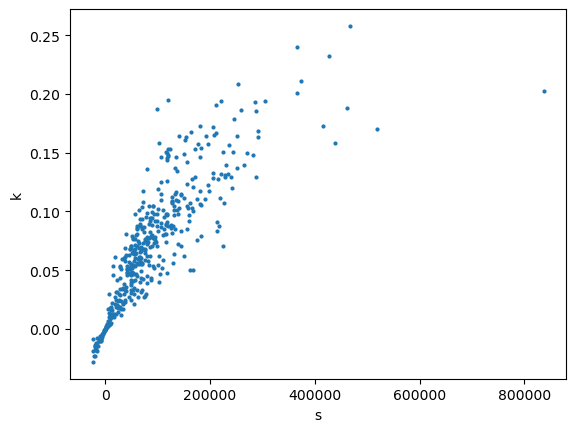

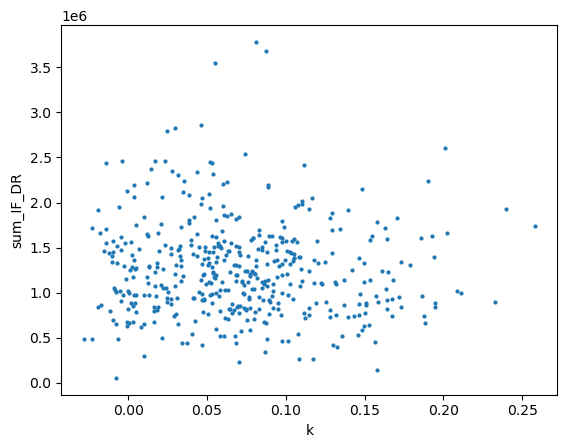

In [61]:
# ============================================================
# Run batch (set FF roots first)
# ============================================================

for ds in DATASETS:
    if ds["ff_if_root"] is None:
        cand = list_roots_from_dir(ds["if_dir"], IF_CH["G"])[:5]
        print(f"[needs ff_if_root] {ds['name']} examples:")
        print(" ", "\n  ".join(cand) if cand else "(no candidates found)")
    if ds["ff_tl_root"] is None:
        cand = list_roots_from_dir(ds["tl_dir"], TL_CH["G"])[:5]
        print(f"[needs ff_tl_root] {ds['name']} examples:")
        print(" ", "\n  ".join(cand) if cand else "(no candidates found)")

max_pairs = None
df_all = run_batch(max_pairs=max_pairs, verbose=True)
print("Rows:", len(df_all))
print(df_all.head())

# --- downstream calculations (same formulas as your single-FOV section) ---
mR = 0.06
mG = 6
alpha = 1.2

df_all['ratio'] = df_all['sum_TL_G'] / df_all['sum_TL_R']
df_all['k'] = mG * mR * (1 - df_all['ratio'] / alpha) / (mR * df_all['ratio'] / alpha - mG)
df_all['s'] = df_all['sum_TL_G'] * df_all['k'] * (mG + df_all['k']) / mG
df_all['sum_BG'] = df_all['s'] / (mG + df_all['k'])
df_all['P_tot'] = df_all['sum_TL_G'] + df_all['sum_BG']

# Optional: save
out_dir = os.path.join(os.getcwd(), "sox2-variability2-output")
os.makedirs(out_dir, exist_ok=True)
out_csv = os.path.join(out_dir, "mESCs Rep1 all proteins true version v2 test1.csv")
df_all.to_csv(out_csv, index=False)
print("Saved:", out_csv)

# Optional: same quick plots as before
plt.figure()
plt.scatter(df_all.s, df_all.k, s=4)
plt.xlabel("s")
plt.ylabel("k")
plt.show()

plt.figure()
if "sum_IF_DR" in df_all.columns:
    plt.scatter(df_all.k, df_all.sum_IF_DR, s=4)
    plt.xlabel("k")
    plt.ylabel("sum_IF_DR")
    plt.show()